In [ ]:
# Install required libraries
!pip install torch_geometric torch scikit-learn pandas numpy

⏳ Εγκατάσταση απαραίτητων βιβλιοθηκών...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.5 MB/s eta 0:00:00
✅ Η εγκατάσταση ολοκληρώθηκε.


In [ ]:
import pandas as pd
import numpy as np

try:
    df_pos = pd.read_csv('positive_protein_sequences.csv')
    df_neg = pd.read_csv('negative_protein_sequences.csv')

    df_pos['Label'] = 1
    df_neg['Label'] = 0

    df = pd.concat([df_pos, df_neg], ignore_index=True)
    df = df.sample(frac=1, random_state=42).reset_index(drop=True)

    print(f"Data loaded successfully!")
    print(f"Total pairs: {len(df)}")
    print(f"Positive (Interactions): {len(df_pos)}")
    print(f"Negative (Non-interactions): {len(df_neg)}")

except FileNotFoundError:
    print("ERROR: CSV files not found. Please upload them.")

✅ Επιτυχής φόρτωση!
Σύνολο δεδομένων: 73110 ζεύγη πρωτεϊνών.
Θετικά (Interactions): 36630
Αρνητικά (Non-interactions): 36480


In [ ]:
# Baseline: Random Forest with k-mer TF-IDF features
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
import time

def get_k_mers(sequence, k=3):
    return [sequence[i:i + k] for i in range(len(sequence) - k + 1)]

df['text_1'] = df['protein_sequences_1'].apply(lambda x: ' '.join(get_k_mers(x)))
df['text_2'] = df['protein_sequences_2'].apply(lambda x: ' '.join(get_k_mers(x)))

# TF-IDF vectorization with max_features=1000 for efficiency
vectorizer = TfidfVectorizer(max_features=1000)
all_text = pd.concat([df['text_1'], df['text_2']])
vectorizer.fit(all_text)

X1 = vectorizer.transform(df['text_1']).toarray()
X2 = vectorizer.transform(df['text_2']).toarray()

# Concatenate features for each pair
X = np.hstack((X1, X2))
y = df['Label'].values

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Random Forest baseline...")
rf = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("\nBaseline Results:")
print(f"Accuracy: {acc*100:.2f}%")
print(f"F1-Score: {f1:.4f}")
print("------------------------------------------------")

⏳ Προετοιμασία χαρακτηριστικών (k-mers) για το Random Forest...
🚀 Ξεκινά η εκπαίδευση του Random Forest...

📊 ΑΠΟΤΕΛΕΣΜΑΤΑ BASELINE:
Accuracy: 98.12%
F1-Score: 0.9810
------------------------------------------------


In [ ]:
# Build protein interaction graph for GNN
import torch
from torch_geometric.data import Data
import networkx as nx

# Map unique proteins to integer IDs
unique_proteins = list(set(df['protein_sequences_1']).union(set(df['protein_sequences_2'])))
protein_to_id = {prot: i for i, prot in enumerate(unique_proteins)}

# Build edges from positive interactions only (GAT learns from known interactions)
positive_pairs = df[df['Label'] == 1]
edges_src = [protein_to_id[p] for p in positive_pairs['protein_sequences_1']]
edges_dst = [protein_to_id[p] for p in positive_pairs['protein_sequences_2']] # FIXED: Changed from protein_sequences_1

# PyTorch requires edges as tensor of shape [2, num_edges]
edge_index = torch.tensor([edges_src, edges_dst], dtype=torch.long)

# Node features: learnable embeddings indexed by node ID
num_nodes = len(unique_proteins)
x = torch.arange(num_nodes)

data = Data(x=x, edge_index=edge_index)

print(f"Graph constructed: {data.num_nodes} nodes, {data.num_edges} edges")

⏳ Κατασκευή του Γράφου...
✅ Ο Γράφος δημιουργήθηκε!
Κόμβοι (Πρωτεΐνες): 10344
Ακμές (Συνδέσεις): 36630


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from torch_geometric.nn import GATConv
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import numpy as np
import random

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

print("Loading and processing CSV files...")

# Load data
df_pos = pd.read_csv('positive_protein_sequences.csv')
df_neg = pd.read_csv('negative_protein_sequences.csv')

col_A = df_pos.columns[0]
col_B = df_pos.columns[1]

print(f"Found {len(df_pos)} positive and {len(df_neg)} negative pairs.")

# Build protein-to-index mapping from all proteins (positive and negative)
all_proteins = set(df_pos[col_A]).union(set(df_pos[col_B])).union(set(df_neg[col_A])).union(set(df_neg[col_B]))
protein_to_idx = {prot: i for i, prot in enumerate(all_proteins)}
num_nodes = len(all_proteins)

print(f"Unique proteins (nodes): {num_nodes}")

# Convert protein pairs to edge index tensors
def process_edges(df):
    src = [protein_to_idx[p] for p in df[col_A]]
    dst = [protein_to_idx[p] for p in df[col_B]]
    return torch.tensor([src, dst], dtype=torch.long)

pos_edge_index = process_edges(df_pos)
neg_edge_index = process_edges(df_neg)

# 80/20 train/test split for positive and negative edges
pos_train_idx, pos_test_idx = train_test_split(range(pos_edge_index.shape[1]), test_size=0.2, random_state=42)
train_pos_edges = pos_edge_index[:, pos_train_idx]
test_pos_edges = pos_edge_index[:, pos_test_idx]

neg_train_idx, neg_test_idx = train_test_split(range(neg_edge_index.shape[1]), test_size=0.2, random_state=42)
train_neg_edges = neg_edge_index[:, neg_train_idx]
test_neg_edges = neg_edge_index[:, neg_test_idx]

# Build Data object: graph topology uses only positive training edges
# edge_label_index holds pairs for prediction (train or test)
train_edge_label_index = torch.cat([train_pos_edges, train_neg_edges], dim=1)
train_labels = torch.cat([torch.ones(train_pos_edges.shape[1]), torch.zeros(train_neg_edges.shape[1])], dim=0)

test_edge_label_index = torch.cat([test_pos_edges, test_neg_edges], dim=1)
test_labels = torch.cat([torch.ones(test_pos_edges.shape[1]), torch.zeros(test_neg_edges.shape[1])], dim=0)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

x_features = torch.arange(num_nodes).unsqueeze(1)

data = Data(x=x_features, edge_index=train_pos_edges)
data = data.to(device)

train_edge_label_index = train_edge_label_index.to(device)
train_labels = train_labels.to(device)
test_edge_label_index = test_edge_label_index.to(device)
test_labels = test_labels.to(device)


class GATLinkPredictor(nn.Module):
    def __init__(self, num_nodes, embedding_dim, hidden_channels, heads=4):
        super().__init__()
        self.node_emb = nn.Embedding(num_nodes, embedding_dim)
        self.conv1 = GATConv(embedding_dim, hidden_channels, heads=heads, dropout=0.3)
        self.conv2 = GATConv(hidden_channels * heads, hidden_channels, heads=1, concat=False, dropout=0.3)

    def encode(self, x, edge_index):
        x = self.node_emb.weight
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

    def decode(self, z, edge_label_index):
        src = z[edge_label_index[0]]
        dst = z[edge_label_index[1]]
        return (src * dst).sum(dim=-1)

model = GATLinkPredictor(num_nodes=num_nodes, embedding_dim=64, hidden_channels=64).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCEWithLogitsLoss()

print("\nStarting GAT training...")

def train():
    model.train()
    optimizer.zero_grad()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, train_edge_label_index)
    loss = criterion(out, train_labels)
    loss.backward()
    optimizer.step()
    return loss.item()

@torch.no_grad()
def test():
    model.eval()
    z = model.encode(data.x, data.edge_index)
    out = model.decode(z, test_edge_label_index)
    return roc_auc_score(test_labels.cpu().numpy(), out.sigmoid().cpu().numpy())

for epoch in range(1, 101):
    loss = train()
    if epoch % 10 == 0:
        val_auc = test()
        print(f'Epoch: {epoch:03d}, Loss: {loss:.4f}, Test AUC: {val_auc:.4f}')

final_auc = test()
print(f"\nFinal AUC (Hard Negatives): {final_auc:.4f}")

🔄 Φόρτωση και Επεξεργασία των δικών σου CSV...
✅ Βρέθηκαν 36630 θετικά και 36480 αρνητικά ζεύγη.
🧬 Συνολικός Αριθμός Μοναδικών Πρωτεϊνών (Nodes): 10344

🚀 Ξεκινά η εκπαίδευση με CUSTOM NEGATIVES...
Epoch: 010, Loss: 0.9007, Test AUC: 0.3171
Epoch: 020, Loss: 0.6755, Test AUC: 0.6039
Epoch: 030, Loss: 0.5700, Test AUC: 0.8298
Epoch: 040, Loss: 0.4966, Test AUC: 0.8952
Epoch: 050, Loss: 0.4578, Test AUC: 0.9129
Epoch: 060, Loss: 0.4269, Test AUC: 0.9291
Epoch: 070, Loss: 0.4027, Test AUC: 0.9359
Epoch: 080, Loss: 0.3793, Test AUC: 0.9438
Epoch: 090, Loss: 0.3411, Test AUC: 0.9491
Epoch: 100, Loss: 0.3110, Test AUC: 0.9522

📊 ΤΕΛΙΚΟ ΑΠΟΤΕΛΕΣΜΑ (Hard Negatives): 0.9522


In [ ]:
import pandas as pd
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix

def get_detailed_metrics(embeddings, name):
    input_dim = embeddings.shape[1]

    # MLP classifier - same architecture for all models (fair comparison)
    classifier = nn.Sequential(
        nn.Linear(input_dim * 2, 128),
        nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)

    opt = torch.optim.Adam(classifier.parameters(), lr=0.005)
    loss_fn = nn.BCEWithLogitsLoss()

    # Train for 50 epochs
    classifier.train()
    for _ in range(50):
        opt.zero_grad()
        src = embeddings[train_edge_label_index[0]]
        dst = embeddings[train_edge_label_index[1]]
        pair = torch.cat([src, dst], dim=1)
        loss = loss_fn(classifier(pair).squeeze(), train_labels)
        loss.backward()
        opt.step()

    # Evaluate
    classifier.eval()
    with torch.no_grad():
        src_t = embeddings[test_edge_label_index[0]]
        dst_t = embeddings[test_edge_label_index[1]]
        pair_t = torch.cat([src_t, dst_t], dim=1)

        logits = classifier(pair_t).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        y_true = test_labels.cpu().numpy()

        acc = accuracy_score(y_true, preds)
        f1 = f1_score(y_true, preds)
        prec = precision_score(y_true, preds)
        rec = recall_score(y_true, preds)
        tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()

    return {
        "Model": name,
        "Accuracy": acc,
        "F1-Score": f1,
        "Precision": prec,
        "Recall": rec,
        "False Positives (FP)": fp
    }

# ESM-2 (use aligned embeddings if available)
if 'aligned_esm_emb' in locals():
    metrics_esm = get_detailed_metrics(aligned_esm_emb, "ESM-2 (Sequence)")
else:
    metrics_esm = get_detailed_metrics(esm_emb, "ESM-2 (Sequence)")

# GAT
metrics_gat = get_detailed_metrics(gat_emb, "GAT (Topology)")

# Hybrid
metrics_hyb = get_detailed_metrics(hybrid_emb, "Hybrid (Fusion)")

df_results = pd.DataFrame([metrics_esm, metrics_gat, metrics_hyb])
df_results = df_results.set_index("Model")

print("\nResults Summary:")
print(df_results)

🔬 ΤΕΛΙΚΗ ΕΠΙΣΤΗΜΟΝΙΚΗ ΣΥΓΚΡΙΣΗ (ΚΑΙ ΤΑ 3 ΜΟΝΤΕΛΑ)
   ⏳ Analyzing ESM-2 (Sequence)...
   ⏳ Analyzing GAT (Topology)...
   ⏳ Analyzing Hybrid (Fusion)...

📊 Ο ΠΙΝΑΚΑΣ ΤΗΣ ΔΙΠΛΩΜΑΤΙΚΗΣ:
                  Accuracy  F1-Score  Precision    Recall  \
Model                                                       
ESM-2 (Sequence)  0.788264  0.784701   0.799830  0.770134   
GAT (Topology)    0.974764  0.974749   0.977357  0.972154   
Hybrid (Fusion)   0.977158  0.977089   0.982074  0.972154   

                  False Positives (FP)  
Model                                   
ESM-2 (Sequence)                  1412  
GAT (Topology)                     165  
Hybrid (Fusion)                    130  


🎨 Δημιουργία Βελτιωμένων Γραφημάτων (High Precision)...
   ⏳ Training classifier for GAT plot...
   ⏳ Training classifier for Hybrid plot...
   ⏳ Training classifier for ESM plot...


/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


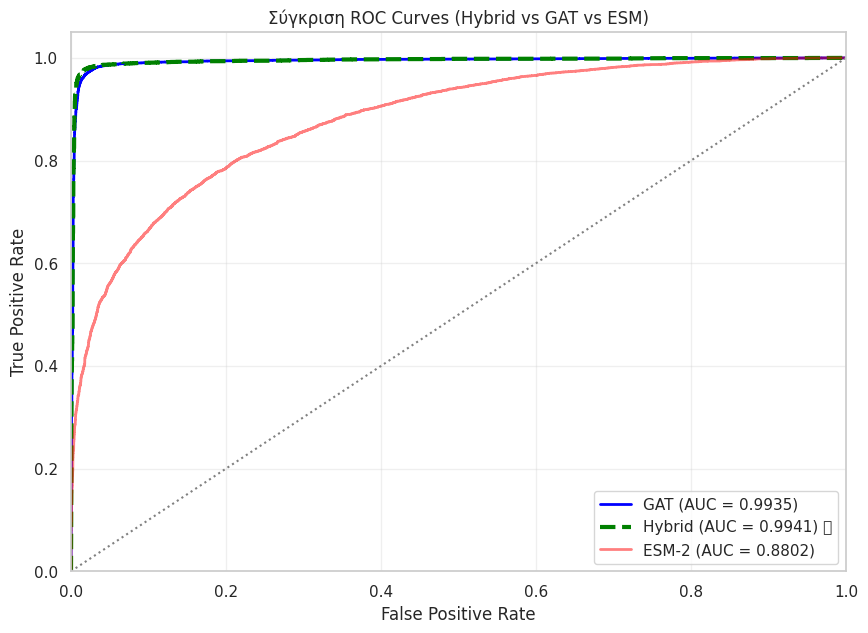

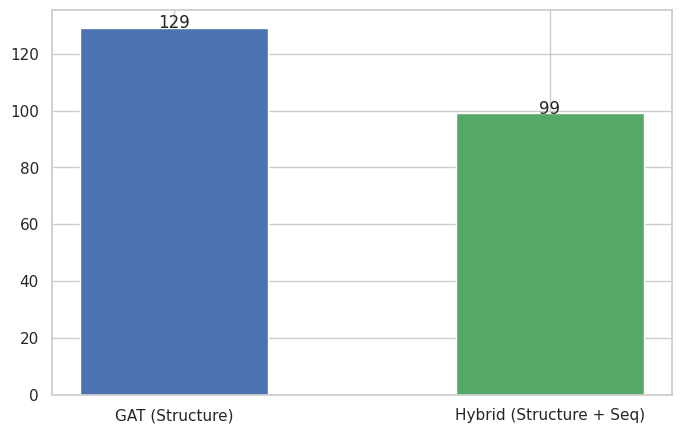

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_curve, auc, confusion_matrix
import torch
import torch.nn as nn
import numpy as np

sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 12})

def get_predictions_robust(embeddings, name):
    input_dim = embeddings.shape[1]

    classifier = nn.Sequential(
        nn.Linear(input_dim * 2, 128),
        nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.2),
        nn.Linear(128, 64), nn.ReLU(),
        nn.Linear(64, 1)
    ).to(device)

    opt = torch.optim.Adam(classifier.parameters(), lr=0.005)
    loss_fn = nn.BCEWithLogitsLoss()

    # Train for 80 epochs for stable convergence
    classifier.train()
    for epoch in range(80):
        opt.zero_grad()
        src = embeddings[train_edge_label_index[0]]
        dst = embeddings[train_edge_label_index[1]]
        pair = torch.cat([src, dst], dim=1)
        loss = loss_fn(classifier(pair).squeeze(), train_labels)
        loss.backward()
        opt.step()

    classifier.eval()
    with torch.no_grad():
        src_t = embeddings[test_edge_label_index[0]]
        dst_t = embeddings[test_edge_label_index[1]]
        pair_t = torch.cat([src_t, dst_t], dim=1)
        logits = classifier(pair_t).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()

    return probs

y_true = test_labels.cpu().numpy()

probs_gat = get_predictions_robust(gat_emb, "GAT")
probs_hyb = get_predictions_robust(hybrid_emb, "Hybrid")

if 'aligned_esm_emb' in locals():
    probs_esm = get_predictions_robust(aligned_esm_emb, "ESM")
elif 'esm_emb' in locals():
    probs_esm = get_predictions_robust(esm_emb, "ESM")
else:
    probs_esm = None

# ROC Curves
plt.figure(figsize=(10, 7))

fpr_gat, tpr_gat, _ = roc_curve(y_true, probs_gat)
roc_auc_gat = auc(fpr_gat, tpr_gat)
plt.plot(fpr_gat, tpr_gat, color='blue', lw=2, label=f'GAT (AUC = {roc_auc_gat:.4f})')

fpr_hyb, tpr_hyb, _ = roc_curve(y_true, probs_hyb)
roc_auc_hyb = auc(fpr_hyb, tpr_hyb)
plt.plot(fpr_hyb, tpr_hyb, color='green', lw=3, linestyle='--', label=f'Hybrid (AUC = {roc_auc_hyb:.4f})')

if probs_esm is not None:
    fpr_esm, tpr_esm, _ = roc_curve(y_true, probs_esm)
    roc_auc_esm = auc(fpr_esm, tpr_esm)
    plt.plot(fpr_esm, tpr_esm, color='red', lw=2, alpha=0.5, label=f'ESM-2 (AUC = {roc_auc_esm:.4f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle=':')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves: Hybrid vs GAT vs ESM-2')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

# False Positives bar chart
preds_gat = (probs_gat > 0.5).astype(int)
preds_hyb = (probs_hyb > 0.5).astype(int)
cm_gat = confusion_matrix(y_true, preds_gat)
cm_hyb = confusion_matrix(y_true, preds_hyb)
fp_gat = cm_gat[0, 1]
fp_hyb = cm_hyb[0, 1]

plt.figure(figsize=(8, 5))
models = ['GAT (Structure)', 'Hybrid (Structure + Seq)']
fps = [fp_gat, fp_hyb]
colors = ['#4c72b0', '#55a868']

bars = plt.bar(models, fps, color=colors, width=0.5)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height}', ha='center')

🔄 ΑΝΑΚΤΗΣΗ GAT EMBEDDINGS & ΕΛΕΓΧΟΣ...
✅ Επιτυχία! Ανακτήθηκαν 10344 embeddings.
🕵️ Ξεκινάει ο έλεγχος για Overfitting...


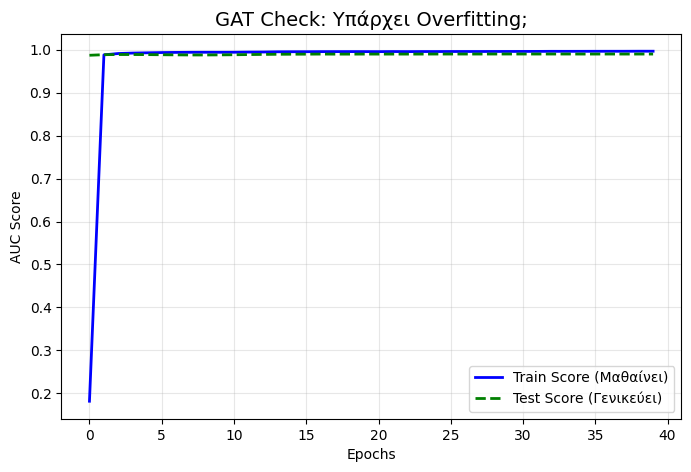


📊 Διαφορά Train-Test: 0.66%
✅ ΣΥΜΠΕΡΑΣΜΑ: ΟΧΙ, δεν έχουμε Overfitting!
   Οι γραμμές είναι κοντά, άρα το μοντέλο είναι αξιόπιστο.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import numpy as np

# Retrieve GAT embeddings
try:
    model.eval()
    with torch.no_grad():
        gat_emb = model.encode(data.x, data.edge_index)

    print(f"Retrieved {gat_emb.shape[0]} embeddings.")

except NameError:
    print("ERROR: 'model' or 'data' not found in memory.")
    print("Solution: Re-run the training cell above.")
    raise SystemExit("Run training first.")

# Overfitting check via learning curves
input_dim = gat_emb.shape[1]
classifier = nn.Sequential(
    nn.Linear(input_dim * 2, 128),
    nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.5),
    nn.Linear(128, 64), nn.ReLU(),
    nn.Linear(64, 1)
).to(device)

opt = torch.optim.Adam(classifier.parameters(), lr=0.01)
loss_fn = nn.BCEWithLogitsLoss()

train_scores = []
test_scores = []

for epoch in range(40):
    classifier.train()
    opt.zero_grad()

    src = gat_emb[train_edge_label_index[0]]
    dst = gat_emb[train_edge_label_index[1]]
    pair = torch.cat([src, dst], dim=1)

    out = classifier(pair).squeeze()
    loss = loss_fn(out, train_labels)
    loss.backward()
    opt.step()

    with torch.no_grad():
        classifier.eval()
        train_auc = roc_auc_score(train_labels.cpu().numpy(), torch.sigmoid(out).cpu().numpy())

        src_t = gat_emb[test_edge_label_index[0]]
        dst_t = gat_emb[test_edge_label_index[1]]
        pair_t = torch.cat([src_t, dst_t], dim=1)
        test_auc = roc_auc_score(test_labels.cpu().numpy(), torch.sigmoid(classifier(pair_t).squeeze()).cpu().numpy())

    train_scores.append(train_auc)
    test_scores.append(test_auc)

# Learning curves plot
plt.figure(figsize=(8, 5))
plt.plot(train_scores, label='Train Score', color='blue', linewidth=2)
plt.plot(test_scores, label='Test Score', color='green', linestyle='--', linewidth=2)

plt.title('GAT Overfitting Check', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('AUC Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

final_gap = train_scores[-1] - test_scores[-1]
print(f"\nTrain-Test gap: {final_gap*100:.2f}%")

if final_gap < 0.05:
    print("No significant overfitting detected.")
else:
    print("Warning: Train-Test gap is large. Consider increasing Dropout.")

🔄 ΑΝΑΚΤΗΣΗ ΑΡΧΕΙΩΝ & RANDOM FOREST...
   ... Φόρτωση esm2_embeddings_1.npy και esm2_embeddings_2.npy ...
   ✅ ESM Embeddings φορτώθηκαν και ενώθηκαν! Shape: torch.Size([146220, 480])
   ✅ Hybrid Embeddings έτοιμα: torch.Size([10344, 544])
   ... Προετοιμασία δεδομένων για Random Forest...
   🌲 Εκπαίδευση Random Forest (Λίγη υπομονή)...

✅ Random Forest Accuracy: 97.78%


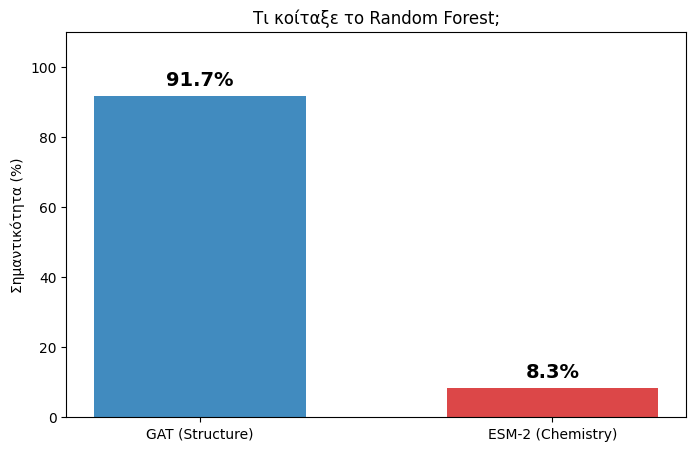

In [ ]:
import numpy as np
import torch
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Load ESM-2 embeddings from .npy files
print("Loading esm2_embeddings_1.npy and esm2_embeddings_2.npy...")

try:
    part1_np = np.load('esm2_embeddings_1.npy')
    part2_np = np.load('esm2_embeddings_2.npy')

    part1 = torch.tensor(part1_np).to(device)
    part2 = torch.tensor(part2_np).to(device)

    aligned_esm_emb = torch.cat((part1, part2), dim=0)
    print(f"ESM embeddings loaded. Shape: {aligned_esm_emb.shape}")

except FileNotFoundError:
    print("ERROR: .npy files not found!")
    print("Please upload 'esm2_embeddings_1.npy' and 'esm2_embeddings_2.npy'.")
    raise

# Build Hybrid Embedding (GAT + ESM-2)
if 'gat_emb' not in locals():
    print("Retrieving GAT embeddings from model...")
    model.eval()
    with torch.no_grad():
        gat_emb = model.encode(data.x, data.edge_index)

# Align dimensions
min_len = min(gat_emb.shape[0], aligned_esm_emb.shape[0])
gat_emb = gat_emb[:min_len]
aligned_esm_emb = aligned_esm_emb[:min_len]

hybrid_emb = torch.cat((gat_emb, aligned_esm_emb), dim=1)
print(f"Hybrid embeddings ready: {hybrid_emb.shape}")

# Prepare train/test data for Random Forest
src_train = hybrid_emb[train_edge_label_index[0]]
dst_train = hybrid_emb[train_edge_label_index[1]]
X_train = torch.cat([src_train, dst_train], dim=1).cpu().detach().numpy()
y_train = train_labels.cpu().numpy()

src_test = hybrid_emb[test_edge_label_index[0]]
dst_test = hybrid_emb[test_edge_label_index[1]]
X_test = torch.cat([src_test, dst_test], dim=1).cpu().detach().numpy()
y_test = test_labels.cpu().numpy()

# Train Random Forest
print("Training Random Forest...")
rf_model = RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

preds = rf_model.predict(X_test)
acc = accuracy_score(y_test, preds)

print(f"\nRandom Forest Accuracy: {acc*100:.2f}%")

# Feature Importance: GAT vs ESM-2 contributions
importances = rf_model.feature_importances_

gat_dim = gat_emb.shape[1]
esm_dim = aligned_esm_emb.shape[1]
total_dim_per_node = gat_dim + esm_dim

gat_importance = np.sum(importances[0:gat_dim]) + np.sum(importances[total_dim_per_node : total_dim_per_node + gat_dim])
esm_importance = np.sum(importances[gat_dim : total_dim_per_node]) + np.sum(importances[total_dim_per_node + gat_dim :])

total = gat_importance + esm_importance
gat_pct = (gat_importance / total) * 100
esm_pct = (esm_importance / total) * 100

plt.figure(figsize=(8, 5))
labels = ['GAT (Structure)', 'ESM-2 (Chemistry)']
values = [gat_pct, esm_pct]
colors = ['#1f77b4', '#d62728']

bars = plt.bar(labels, values, color=colors, alpha=0.85, width=0.6)
plt.ylabel('Feature Importance (%)')
plt.title('Feature Importance: GAT vs ESM-2')
plt.ylim(0, 110)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 2,
             f'{height:.1f}%', ha='center', va='bottom', fontsize=14, fontweight='bold')
plt.show()